# 🏦 Credit Card Fraud Detection Project

This project is inspired by the famous **Credit Card Fraud Detection Dataset** from Kaggle.  
i will use supervised machine learning for this project.
but there is a main big problemin the distribution of the class column , its heavily ibalanced,
so i will compare two approaches to solve this problem :
1 - using class weight parameter 
2-  oversampling technique (smote)


---



## 1-Import Libraries

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV, RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve,auc, RocCurveDisplay

## 2-Load and inspect the dataset 

In [2]:
# Load the data
df = pd.read_csv(r"C:\Users\maria\Downloads\archive (6)\creditcard.csv")

# Shape of the dataset
df.shape

# Display first 5 rows
print(df.head())

# Display last 5 rows
print(df.tail())

# Basic statistics
print(df.describe())

# Check for null values
print(df.isnull().sum()) #no nulls

# Class distribution
print(df['Class'].value_counts()) #very imbalanced dataset 

# Count duplicates
print(df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

## 3-Exploratory Data Analysis(EDA) 

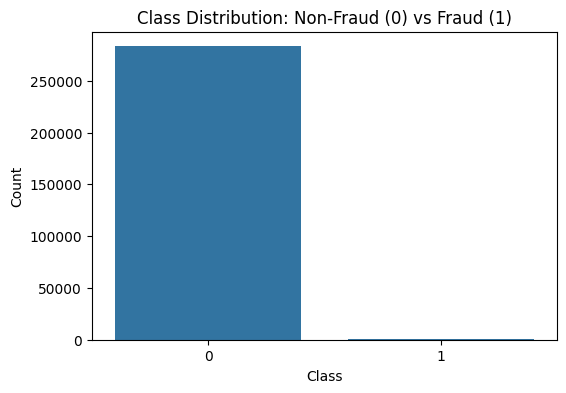

In [3]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution: Non-Fraud (0) vs Fraud (1)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()
# Extreme imbalance (useful for anomaly detection)(unsupervised learning)
# Will apply SMOTE later for (supervised learning)

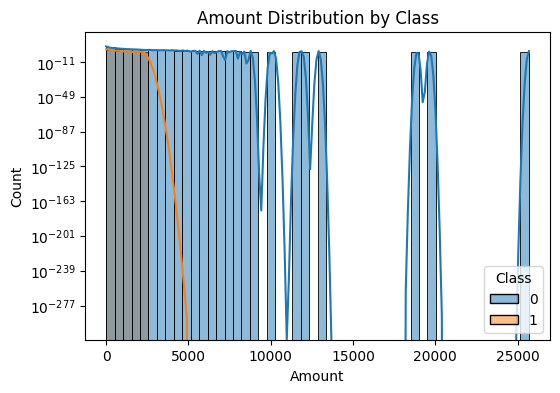

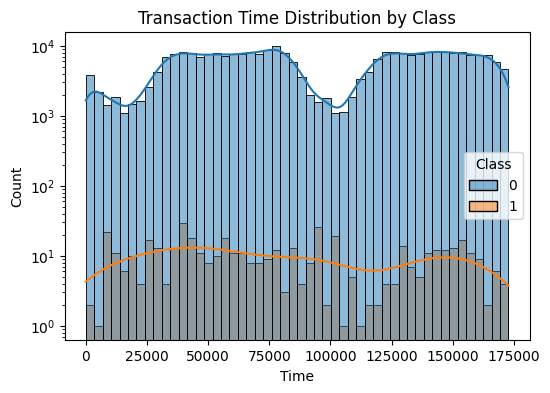

In [4]:
#i will only plot the distributions for amount and time , because all the other columns starting with 'V' are encrypted using 
#PCA , so they are already normalized and scaled.

# 1) Amount Distribution
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='Amount', bins=50, kde=True, hue='Class')
plt.title('Amount Distribution by Class')
plt.yscale('log')
plt.show()

# 2) Time Distribution
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='Time', bins=50, kde=True, hue='Class')
plt.title('Transaction Time Distribution by Class')
plt.yscale('log')
plt.show()

## 4-Feature Engineering

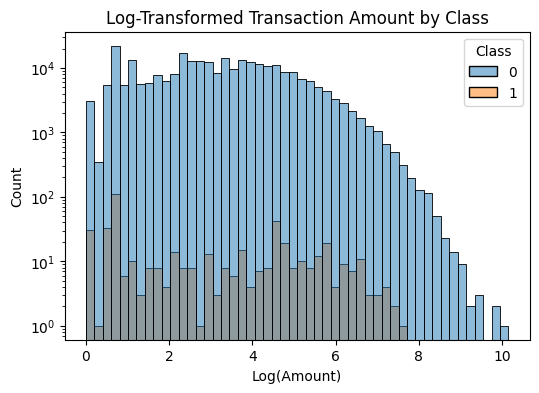

In [5]:
# from the visualizations , amount is very left skewed so we will use log transform 
df['Amount_Log'] = np.log1p(df['Amount'])

# Plot log-transformed Amount distribution by Class
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='Amount_Log', bins=50, hue='Class')
plt.yscale('log')  # Log scale for better visualization of skewed counts
plt.title('Log-Transformed Transaction Amount by Class')
plt.xlabel('Log(Amount)')
plt.ylabel('Count')
plt.show()


In [6]:
#Extracting useful features from the time column
# hour of transaction
df['Hour'] = (df['Time'] // 3600) % 24

# is_night feature (frauds often happen at night)
df['is_night'] = ((df['Hour'] < 6) | (df['Hour'] >= 18)).astype(int)

# day of week feature (0=Sunday, 6=Saturday)
df['day'] = (df['Time'] // (3600*24)) % 7

# Drop original 'Time' and raw 'Amount' columns since we use engineered features
df = df.drop(['Time','Amount'], axis=1, errors='ignore')

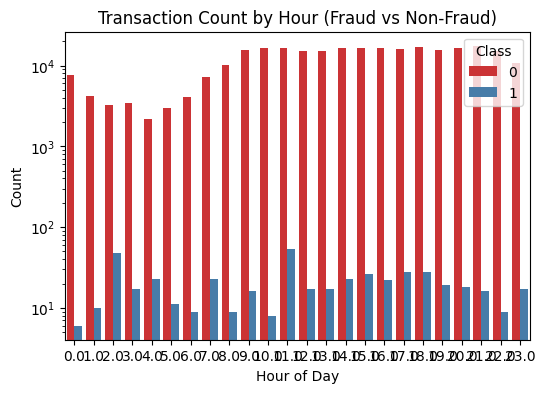

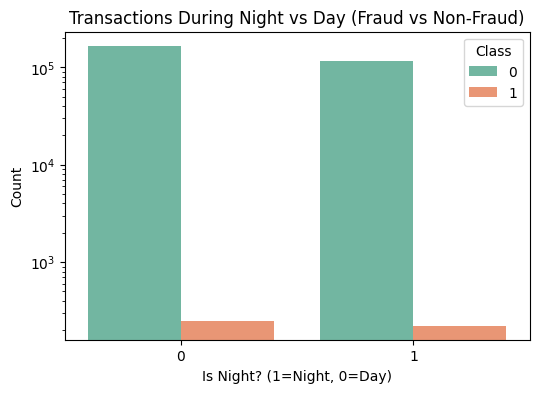

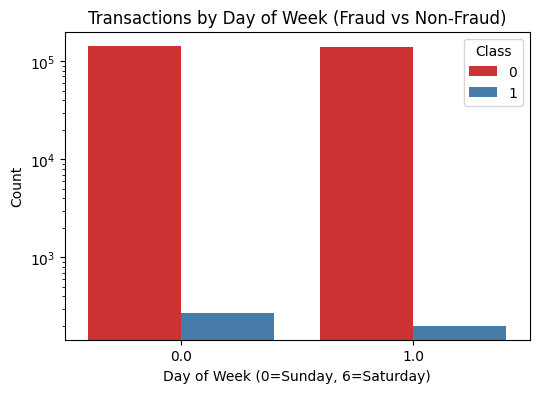

In [7]:
#showing the relationship of the new features with the class column
#Hour
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Hour', hue='Class', palette='Set1')
plt.title('Transaction Count by Hour (Fraud vs Non-Fraud)')
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.yscale('log') 
plt.show()

#is_night
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='is_night', hue='Class', palette='Set2')
plt.title('Transactions During Night vs Day (Fraud vs Non-Fraud)')
plt.xlabel('Is Night? (1=Night, 0=Day)')
plt.ylabel('Count')
plt.yscale('log') 
plt.show()

#Day of week 
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='day', hue='Class', palette='Set1')
plt.title('Transactions by Day of Week (Fraud vs Non-Fraud)')
plt.xlabel('Day of Week (0=Sunday, 6=Saturday)')
plt.ylabel('Count')
plt.yscale('log') 
plt.show() 

## Supervised Learning
## 5-(Train-validation-test-split) 

In [8]:
y=df['Class']
X=df.drop('Class',axis=1)
X_train_val,X_test,y_train_val,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
X_train , X_val , y_train , y_val = train_test_split(X_train_val,y_train_val,test_size=0.25,random_state=42,stratify=y_train_val)
#split into train, validtion and test sets 
#the test set will be only used at the end 
#validation for supervised learning (hyperparameter tuning and choosing the best model)
# must use stratify here to handle the imbalance in the class column 

## 6 - Model Evaluation (SMOTE VS Class weight)

In [9]:
#first technique : using oversampling(SMOTE)

#since the other columns are scaled because pca ws already applied to them , i will scale only those
scaling_columns = ['Amount_Log', 'Hour', 'day']

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), scaling_columns) #apply only scaling to these columns
    ],
    remainder="passthrough"
)

classification_models = {
    'LogisticRegression': {
        'Model': LogisticRegression(random_state=42, max_iter=1000),
        'params': {
            'classifier__C': [0.01, 0.1, 1, 10],
            'classifier__penalty': ['l2']
        }
    },
    'XGBoost': {
        'Model': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
        'params': {
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__n_estimators': [200, 300],
            'classifier__max_depth': [3, 5]
        }
    },
    'LightGBM': {
        'Model': LGBMClassifier(random_state=42),
        'params': {
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__n_estimators': [200, 300],
            'classifier__max_depth': [10, 15]
        }
    },
    'CatBoost': {
        'Model': CatBoostClassifier(random_state=42, verbose=0),
        'params': {
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__depth': [6, 8],
            'classifier__n_estimators': [200, 300]
        }
    } }

best_models = {}

for name, model_dict in classification_models.items():
    print(f"\nRunning GridSearchCV for {name}...")

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),   
        ('classifier', model_dict['Model'])
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=model_dict['params'],
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    y_pred = grid.predict(X_val)

    best_models[name] = grid.best_estimator_
    print("Best Parameters:", grid.best_params_)
    print("ROC-AUC on test set:", roc_auc_score(y_val, grid.predict_proba(X_val)[:, 1]))
    print(classification_report(y_val, y_pred))


Running GridSearchCV for LogisticRegression...
Best Parameters: {'classifier__C': 0.01, 'classifier__penalty': 'l2'}
ROC-AUC on test set: 0.9811119557334437
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.90      0.10        94

    accuracy                           0.97     56745
   macro avg       0.53      0.94      0.54     56745
weighted avg       1.00      0.97      0.98     56745


Running GridSearchCV for XGBoost...


C:\Users\maria\miniconda3\envs\mlenv\lib\site-packages\xgboost\training.py:183: UserWarning: [01:10:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 5, 'classifier__n_estimators': 200}
ROC-AUC on test set: 0.9691023463182751
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.49      0.87      0.63        94

    accuracy                           1.00     56745
   macro avg       0.74      0.94      0.81     56745
weighted avg       1.00      1.00      1.00     56745


Running GridSearchCV for LightGBM...
[LightGBM] [Info] Number of positive: 169951, number of negative: 169951
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.060414 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8160
[LightGBM] [Info] Number of data points in the train set: 339902, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


C:\Users\maria\miniconda3\envs\mlenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Best Parameters: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 10, 'classifier__n_estimators': 300}


C:\Users\maria\miniconda3\envs\mlenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


ROC-AUC on test set: 0.9484602814470233
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.90      0.83      0.86        94

    accuracy                           1.00     56745
   macro avg       0.95      0.91      0.93     56745
weighted avg       1.00      1.00      1.00     56745


Running GridSearchCV for CatBoost...
Best Parameters: {'classifier__depth': 8, 'classifier__learning_rate': 0.05, 'classifier__n_estimators': 200}
ROC-AUC on test set: 0.9750091733747165
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.73      0.86      0.79        94

    accuracy                           1.00     56745
   macro avg       0.86      0.93      0.89     56745
weighted avg       1.00      1.00      1.00     56745



In [13]:
# second technique : using class weight for all models except XGboost , i will use the scale_pos_weight parameter

classification_models2 = {
    'LogisticRegression': {
        'Model': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
        'params': {
            'classifier__C': [0.01, 0.1, 1, 10],
            'classifier__penalty': ['l2']
        }
    },
    'XGBoost': {
        'Model': XGBClassifier(
            random_state=42, 
            use_label_encoder=False, 
            eval_metric='logloss', 
            scale_pos_weight=1  
        ),
        'params': {
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__n_estimators': [200, 300],
            'classifier__max_depth': [3, 5]
        }
    },
    'LightGBM': {
        'Model': LGBMClassifier(
            random_state=42, 
            class_weight='balanced'
        ),
        'params': {
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__n_estimators': [200, 300],
            'classifier__max_depth': [10, 15]
        }
    },
    'CatBoost': {
        'Model': CatBoostClassifier(
            random_state=42, 
            verbose=0, 
            class_weights=[1, 100]  # افتراض: 100 مرة weight للfraud class
        ),
        'params': {
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__depth': [6, 8],
            'classifier__n_estimators': [200, 300]
        }
    }
}
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score

best_models = {}

for name, model_dict in classification_models2.items():
    print(f"\nRunning GridSearchCV for {name}...")

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model_dict['Model'])
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=model_dict['params'],
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)
    y_pred = grid.predict(X_val)

    best_models[name] = grid.best_estimator_

    print("Best Parameters:", grid.best_params_)
    print("ROC-AUC on validation set:", roc_auc_score(y_val, grid.predict_proba(X_val)[:, 1]))
    print(classification_report(y_val, y_pred))



Running GridSearchCV for LogisticRegression...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Parameters: {'classifier__C': 0.01, 'classifier__penalty': 'l2'}
ROC-AUC on validation set: 0.9819150250676313
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.06      0.90      0.11        94

    accuracy                           0.97     56745
   macro avg       0.53      0.94      0.55     56745
weighted avg       1.00      0.97      0.99     56745


Running GridSearchCV for XGBoost...
Fitting 5 folds for each of 8 candidates, totalling 40 fits


C:\Users\maria\miniconda3\envs\mlenv\lib\site-packages\xgboost\training.py:183: UserWarning: [02:15:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 200}
ROC-AUC on validation set: 0.9743441271810942
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.94      0.82      0.88        94

    accuracy                           1.00     56745
   macro avg       0.97      0.91      0.94     56745
weighted avg       1.00      1.00      1.00     56745


Running GridSearchCV for LightGBM...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
[LightGBM] [Info] Number of positive: 284, number of negative: 169951
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.041813 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7425
[LightGBM] [Info] Number of data points in the train set: 170235, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.50000

C:\Users\maria\miniconda3\envs\mlenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Best Parameters: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 10, 'classifier__n_estimators': 300}


C:\Users\maria\miniconda3\envs\mlenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


ROC-AUC on validation set: 0.979630225678163
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.92      0.86      0.89        94

    accuracy                           1.00     56745
   macro avg       0.96      0.93      0.94     56745
weighted avg       1.00      1.00      1.00     56745


Running GridSearchCV for CatBoost...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'classifier__depth': 8, 'classifier__learning_rate': 0.05, 'classifier__n_estimators': 300}
ROC-AUC on validation set: 0.9760555202308123
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.85      0.88        94

    accuracy                           1.00     56745
   macro avg       0.95      0.93      0.94     56745
weighted avg       1.00      1.00      1.00     56745



In [10]:
#Since random forest took forever to run and still didnt display the results after a very long time , i will use randomized search 
# instead of grid search for it only 
#class weight version 
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_jobs=-1, 
        class_weight='balanced',
        random_state=42
    ))
])

param_rf = {
    "classifier__n_estimators": [30, 50, 70],
    "classifier__max_depth": [4, 6, 8],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2],
    "classifier__max_features": ["sqrt"]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_rf,
    n_iter=10,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

y_pred_rf = random_search.predict(X_val)

print("Best Parameters:", random_search.best_params_)
print("ROC-AUC on test set:", roc_auc_score(y_val, random_search.predict_proba(X_val)[:, 1]))
print(classification_report(y_val, y_pred_rf))


Best Parameters: {'classifier__n_estimators': 50, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 6}
ROC-AUC on test set: 0.9747374461850592
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.64      0.88      0.74        94

    accuracy                           1.00     56745
   macro avg       0.82      0.94      0.87     56745
weighted avg       1.00      1.00      1.00     56745



In [12]:
#smote version 
from imblearn.pipeline import Pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(
        n_jobs=-1,
        random_state=42
    ))
])

param_rf = {
    "classifier__n_estimators": [30, 50, 70],
    "classifier__max_depth": [4, 6, 8],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2],
    "classifier__max_features": ["sqrt"]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_rf,
    n_iter=10,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

y_pred_rf = random_search.predict(X_val)

print("Best Parameters:", random_search.best_params_)
print("ROC-AUC on test set:", roc_auc_score(y_val, random_search.predict_proba(X_val)[:, 1]))
print(classification_report(y_val, y_pred_rf))


Best Parameters: {'classifier__n_estimators': 70, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 4}
ROC-AUC on test set: 0.9703911256566428
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56651
           1       0.19      0.89      0.31        94

    accuracy                           0.99     56745
   macro avg       0.59      0.94      0.65     56745
weighted avg       1.00      0.99      1.00     56745



I am going to evaluate the best model for this problem based on the balance between the precision and recall , 
for the smote experience best model was :
LightGBM:

F1-score = 0.89

Precision = 0.92

Recall = 0.86

ROC-AUC = 0.9796

for the class weight experience best model was:
Catboost with :
F1-score ≈ 0.79

Precision = 0.73

Recall = 0.86

ROC-AUC ≈ 0.975

## overall  best model :light gbm with class weight 

## Final evaluation on test set 


[LightGBM] [Info] Number of positive: 284, number of negative: 169951
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.027908 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7423
[LightGBM] [Info] Number of data points in the train set: 170235, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


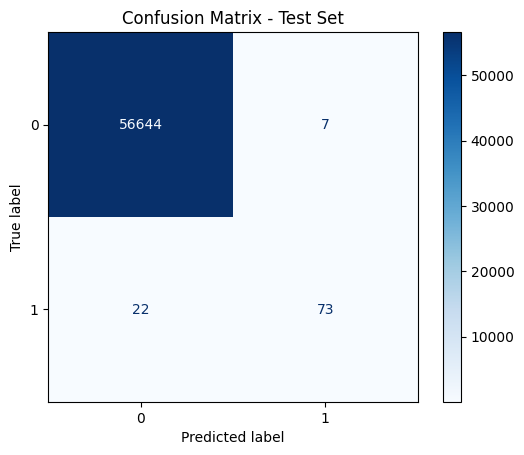

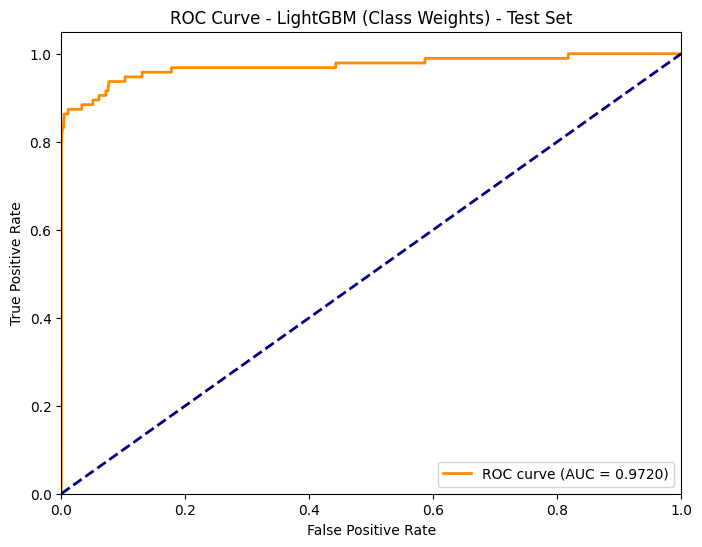

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt
best_model = LGBMClassifier(
    random_state=42, 
    class_weight='balanced',
    learning_rate=0.05, 
    max_depth=10, 
    n_estimators=300
)
best_model.fit(X_train, y_train)
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]  

# plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Test Set")
plt.show()

# plot  ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LightGBM (Class Weights) - Test Set')
plt.legend(loc="lower right")
plt.show()
